# Kalshi Prediction Market Calibration — Research Walkthrough

**Do Kalshi prices mean the same thing across categories and time horizons?**

A 70-cent contract implies a 70% probability — but does that hold equally for politics
30 days out versus crypto 7 days out? This notebook measures calibration across domains
and time, tests whether domain differences survive microstructure controls, and asks
whether an out-of-sample recalibration layer can exploit them.

> **A note on the numbers.** An earlier version of this study reported much stronger
> findings (a 4× calibration spread, an out-of-sample recalibration gain, a Crypto
> "sign flip"). Several rested on measurement artifacts — scoring the final traded price
> after outcomes were public, using whole-lifetime aggregates as controls (which leak the
> outcome), a broken bootstrap, and non-clustered standard errors. This notebook runs the
> **corrected** pipeline. The findings are weaker and, in one case, reverse. That is the
> honest result.

**This notebook imports the analysis functions directly from `src/`** — it is not a
re-implementation, so it always matches `python run_analysis.py --analyze`. Plots are the
ones written to `data/plots/` by that pipeline.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from IPython.display import Image, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

from src.ingest.database import get_connection
from src.analysis.calibration import (
    analysis_overall,
    analysis_accuracy_over_time,
    analysis_domain_time,
    analysis_liquidity,
    analysis_explanatory,
    analysis_regression,
    analysis_recalibration,
    analysis_adjusted_model,
    compute_summary_stats,
)

PLOTS = "data/plots"

conn = get_connection()
features = pd.read_sql_query("SELECT * FROM market_features", conn)
cal_ds = pd.read_sql_query("SELECT * FROM calibration_dataset", conn)
print(f"{len(features)} markets, {len(cal_ds)} pre-close price observations")
print(f"Categories: {features['category'].nunique()}")

489 markets, 15822 pre-close price observations
Categories: 15


## 1. Data Overview

Resolved binary Kalshi markets, drawn top-by-volume within each category (so the sample
is range-restricted on volume — see Limitations in the README). Daily candlesticks, with
hourly backfill for short-lived markets, flagged and normalized to a per-day basis.

In [2]:
print("Markets per category:")
display(features["category"].value_counts())

print("\nOutcome balance (share resolving YES):")
display(features.groupby("category")["result_binary"].mean().round(3).sort_values(ascending=False))

Markets per category:


category
Sports                    73
Politics                  63
Economics                 48
Elections                 45
Entertainment             44
Climate and Weather       44
Companies                 41
Mentions                  41
Financials                28
Social                    22
World                     15
Crypto                    12
Science and Technology    11
Health                     1
Education                  1
Name: count, dtype: int64


Outcome balance (share resolving YES):


category
Health                    1.000
Economics                 0.604
Financials                0.500
Sports                    0.466
Crypto                    0.417
Climate and Weather       0.409
Social                    0.364
Entertainment             0.341
Elections                 0.333
Mentions                  0.293
World                     0.267
Companies                 0.244
Politics                  0.206
Science and Technology    0.182
Education                 0.000
Name: result_binary, dtype: float64

## 2. Analysis A — Overall Calibration

Brier score, log loss and absolute error by category. Lower is better. This view uses the
market-level features; the fixed-horizon correction (below) is the honest accuracy test.


OVERALL CALIBRATION (Final Prices)
  Markets: 430
  Brier Score: 0.1071
  Log Loss: 0.3402
  Abs Error: 0.1976

  By category (final prices):
    Sports                     Brier=0.1267  n=73
    Politics                   Brier=0.0559  n=61
    Climate and Weather        Brier=0.0901  n=44
    Entertainment              Brier=0.0500  n=43
    Companies                  Brier=0.1679  n=41
    Mentions                   Brier=0.2435  n=40
    Economics                  Brier=0.0676  n=36
    Financials                 Brier=0.2454  n=26
    Elections                  Brier=0.0004  n=21
    World                      Brier=0.0046  n=13
    Crypto                     Brier=0.1452  n=12
    Social                     Brier=0.0004  n=12
    Science and Technology     Brier=0.0033  n=7
  Saved overall_calibration.png


,bin_center,mean_predicted,realized_frequency,count,calibration_error
0,0.05,0.019716,0.031447,159,0.011731
1,0.15,0.139048,0.238095,21,0.099048
2,0.25,0.248125,0.125000,32,0.123125
3,0.35,0.353333,0.208333,24,0.145000
4,0.45,0.450952,0.476190,21,0.025238
5,0.55,0.542174,0.304348,23,0.237826
6,0.65,0.659474,0.578947,19,0.080526
7,0.75,0.746429,0.571429,14,0.175000
8,0.85,0.850714,0.714286,14,0.136429
9,0.95,0.974854,0.941748,103,0.033107


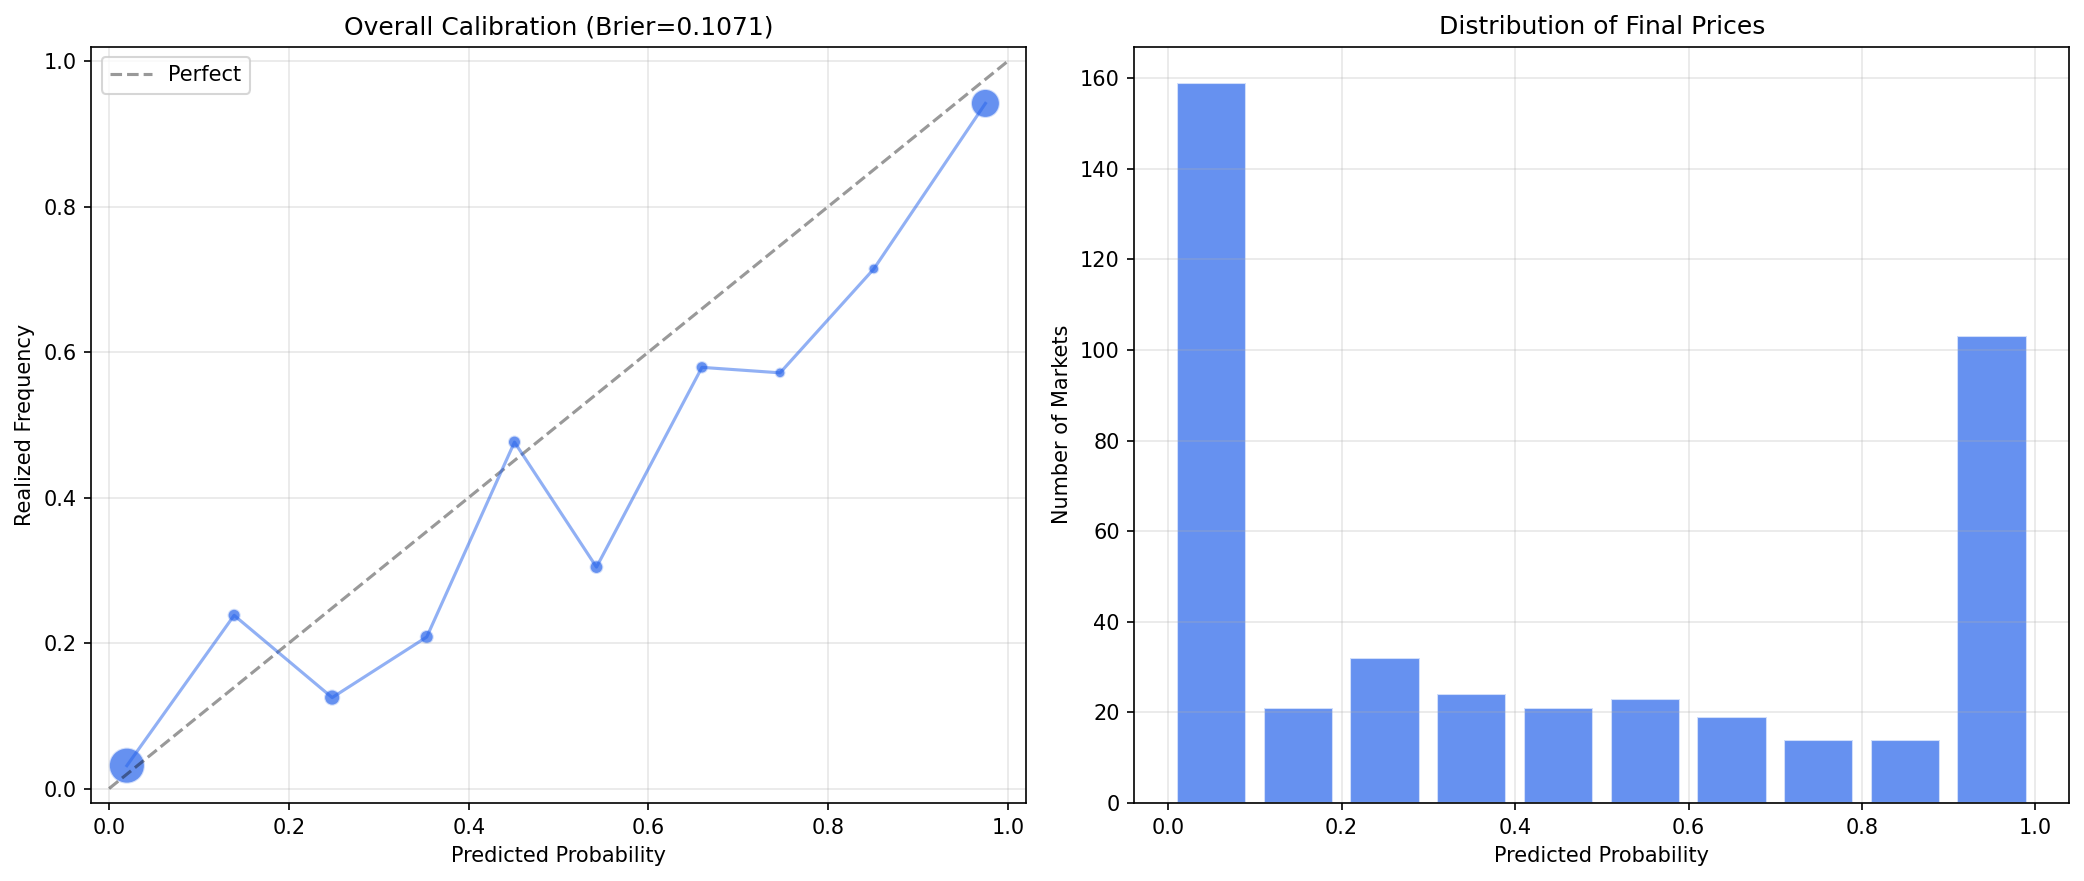

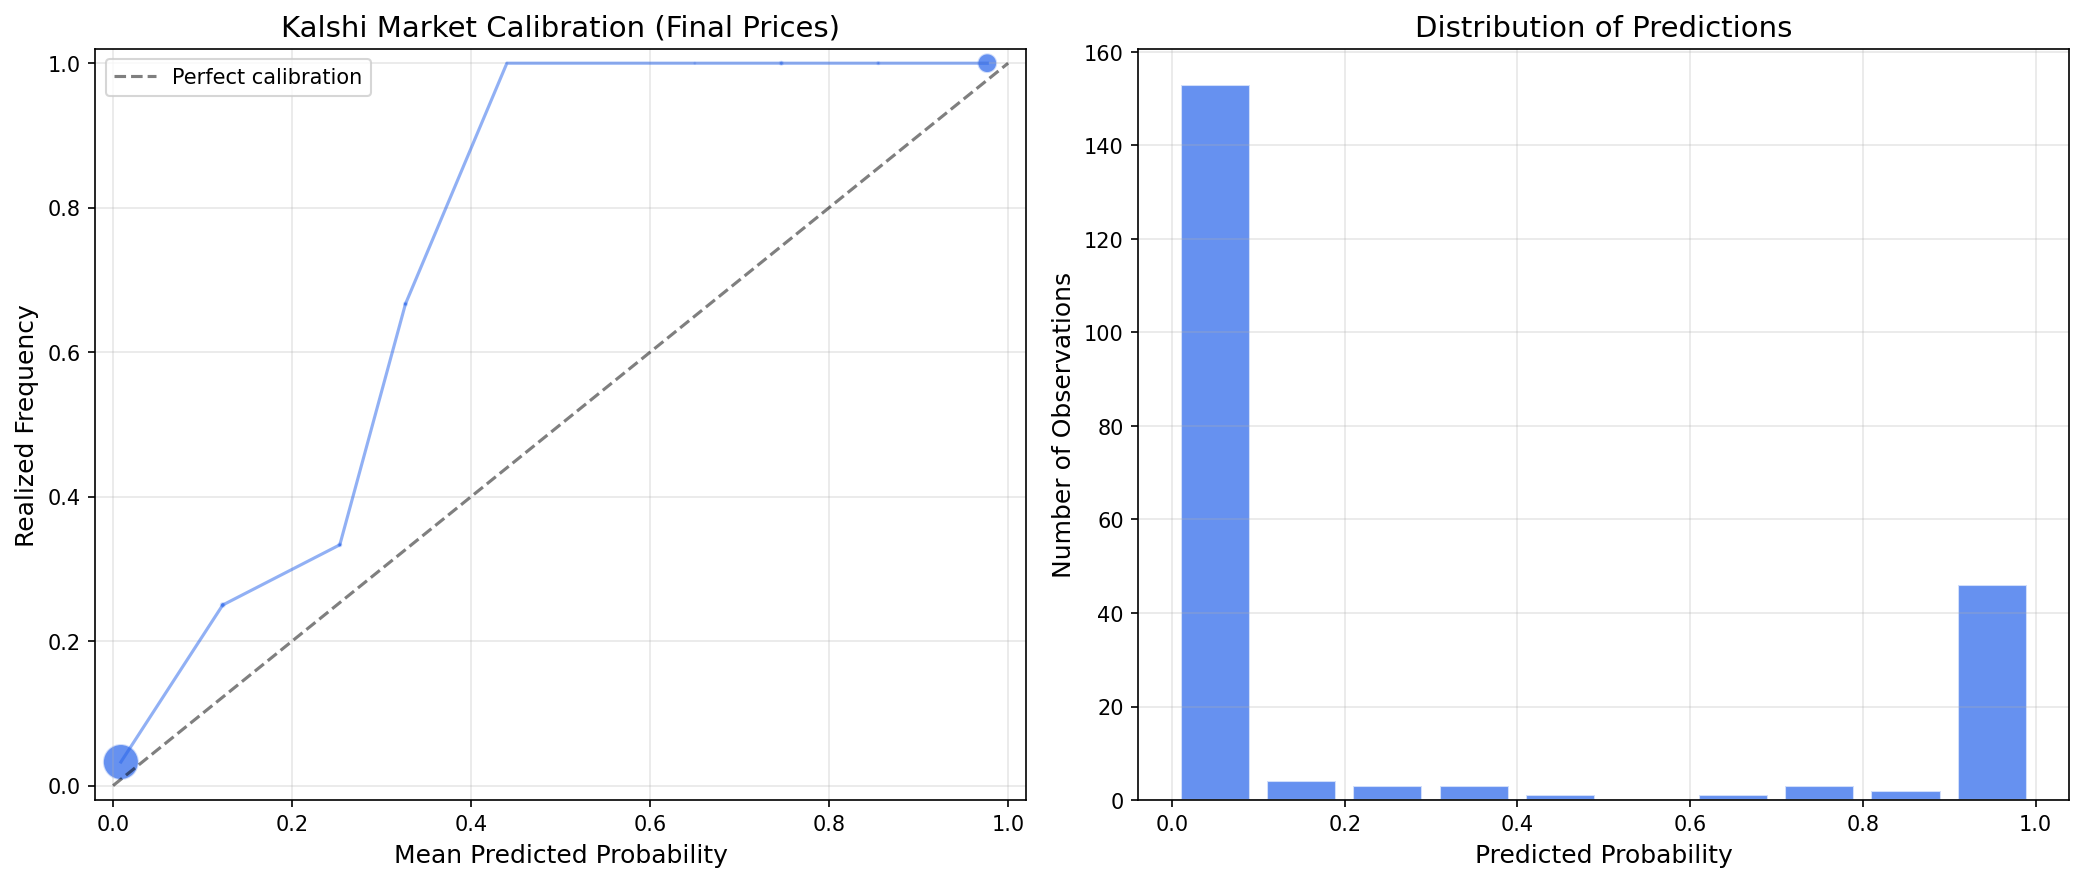

In [3]:
overall = analysis_overall(features)
display(overall["calibration"])
display(Image(f"{PLOTS}/overall_calibration.png"))
display(Image(f"{PLOTS}/calibration_curve.png"))

## 3. Accuracy Over Time — the single most important correction

Scoring a market by its **last** traded price flatters any category whose outcome becomes
public before the market technically closes (a called election trades at 0.99 for days).
Scored **1 / 3 / 7 days before close** — while the outcome is still genuinely uncertain —
the ranking changes and the whole board gets worse.

Politics and Climate genuinely forecast well a day out (~0.11–0.16). Economics and Social,
which looked fine at the last tick, are barely better than a coin flip once scored before
the result is known. Small categories (Crypto, Sci/Tech) are too thin to rank at short
horizons and are shown for completeness only.


ANALYSIS A: Accuracy Over Time


  30+ days         Brier=0.1301  LogLoss=0.4331  AbsErr=0.2525  n=7497 (184 markets)
  7-30 days        Brier=0.1517  LogLoss=0.4722  AbsErr=0.2749  n=4099 (255 markets)


  1-7 days         Brier=0.2154  LogLoss=0.6716  AbsErr=0.3544  n=3017 (408 markets)


  < 24 hours       Brier=0.2104  LogLoss=0.5947  AbsErr=0.3695  n=1209 (414 markets)


  Saved accuracy_over_time.png

=== 30+ days ===


...

,bin_center,mean_predicted,realized_frequency,count,calibration_error,time_horizon,brier_score,log_loss,abs_error,n_observations,n_markets
0,0.05,0.031290,0.043319,1362,0.012029,7-30 days,0.151695,0.472196,0.274934,4099,255
1,0.15,0.143714,0.241611,447,0.097897,7-30 days,0.151695,0.472196,0.274934,4099,255
2,0.25,0.249495,0.361616,495,0.112121,7-30 days,0.151695,0.472196,0.274934,4099,255
3,0.35,0.345992,0.366412,262,0.020420,7-30 days,0.151695,0.472196,0.274934,4099,255
4,0.45,0.447685,0.290123,324,0.157562,7-30 days,0.151695,0.472196,0.274934,4099,255
5,0.55,0.545207,0.272727,242,0.272479,7-30 days,0.151695,0.472196,0.274934,4099,255
6,0.65,0.654032,0.510753,186,0.143280,7-30 days,0.151695,0.472196,0.274934,4099,255
7,0.75,0.761875,0.625000,160,0.136875,7-30 days,0.151695,0.472196,0.274934,4099,255
8,0.85,0.850369,0.803279,244,0.047090,7-30 days,0.151695,0.472196,0.274934,4099,255
9,0.95,0.950239,0.920424,377,0.029814,7-30 days,0.151695,0.472196,0.274934,4099,255



=== 1-7 days ===


,bin_center,mean_predicted,realized_frequency,count,calibration_error,time_horizon,brier_score,log_loss,abs_error,n_observations,n_markets
0,0.05,0.026372,0.187879,825,0.161506,1-7 days,0.215418,0.671558,0.354374,3017,408
1,0.15,0.147348,0.201278,313,0.053930,1-7 days,0.215418,0.671558,0.354374,3017,408
2,0.25,0.252973,0.238739,222,0.014234,1-7 days,0.215418,0.671558,0.354374,3017,408
3,0.35,0.352913,0.527508,309,0.174595,1-7 days,0.215418,0.671558,0.354374,3017,408
4,0.45,0.448943,0.642276,369,0.193333,1-7 days,0.215418,0.671558,0.354374,3017,408
5,0.55,0.557773,0.402344,256,0.155430,1-7 days,0.215418,0.671558,0.354374,3017,408
6,0.65,0.641059,0.629412,170,0.011647,1-7 days,0.215418,0.671558,0.354374,3017,408
7,0.75,0.765484,0.406452,155,0.359032,1-7 days,0.215418,0.671558,0.354374,3017,408
8,0.85,0.842773,0.537815,119,0.304958,1-7 days,0.215418,0.671558,0.354374,3017,408
9,0.95,0.958423,0.910394,279,0.048029,1-7 days,0.215418,0.671558,0.354374,3017,408



=== < 24 hours ===


,bin_center,mean_predicted,realized_frequency,count,calibration_error,time_horizon,brier_score,log_loss,abs_error,n_observations,n_markets
0,0.05,0.024972,0.034314,204,0.009342,< 24 hours,0.210354,0.594666,0.369499,1209,414
1,0.15,0.147956,0.226277,137,0.078321,< 24 hours,0.210354,0.594666,0.369499,1209,414
2,0.25,0.263051,0.322034,118,0.058983,< 24 hours,0.210354,0.594666,0.369499,1209,414
3,0.35,0.351545,0.479675,123,0.128130,< 24 hours,0.210354,0.594666,0.369499,1209,414
4,0.45,0.441620,0.659218,179,0.217598,< 24 hours,0.210354,0.594666,0.369499,1209,414
5,0.55,0.550345,0.386207,145,0.164138,< 24 hours,0.210354,0.594666,0.369499,1209,414
6,0.65,0.649625,0.537500,80,0.112125,< 24 hours,0.210354,0.594666,0.369499,1209,414
7,0.75,0.761940,0.492537,67,0.269403,< 24 hours,0.210354,0.594666,0.369499,1209,414
8,0.85,0.840192,0.230769,52,0.609423,< 24 hours,0.210354,0.594666,0.369499,1209,414
9,0.95,0.973462,0.932692,104,0.040769,< 24 hours,0.210354,0.594666,0.369499,1209,414


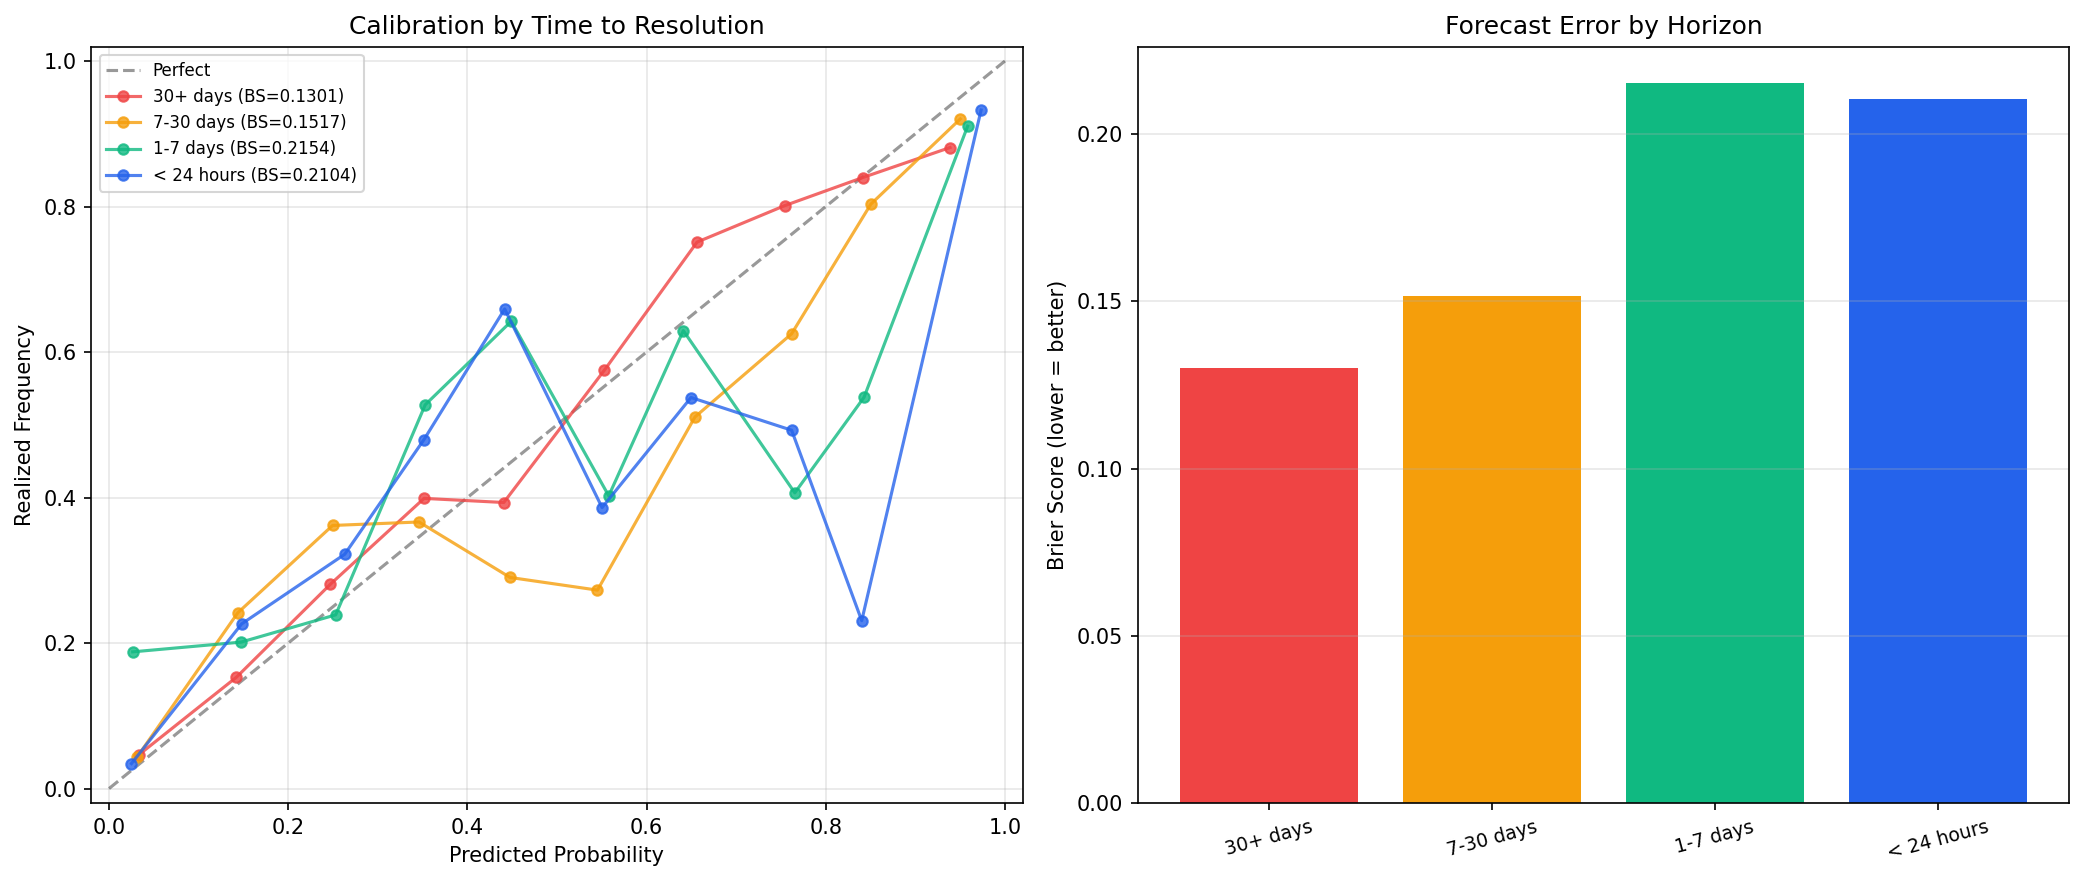

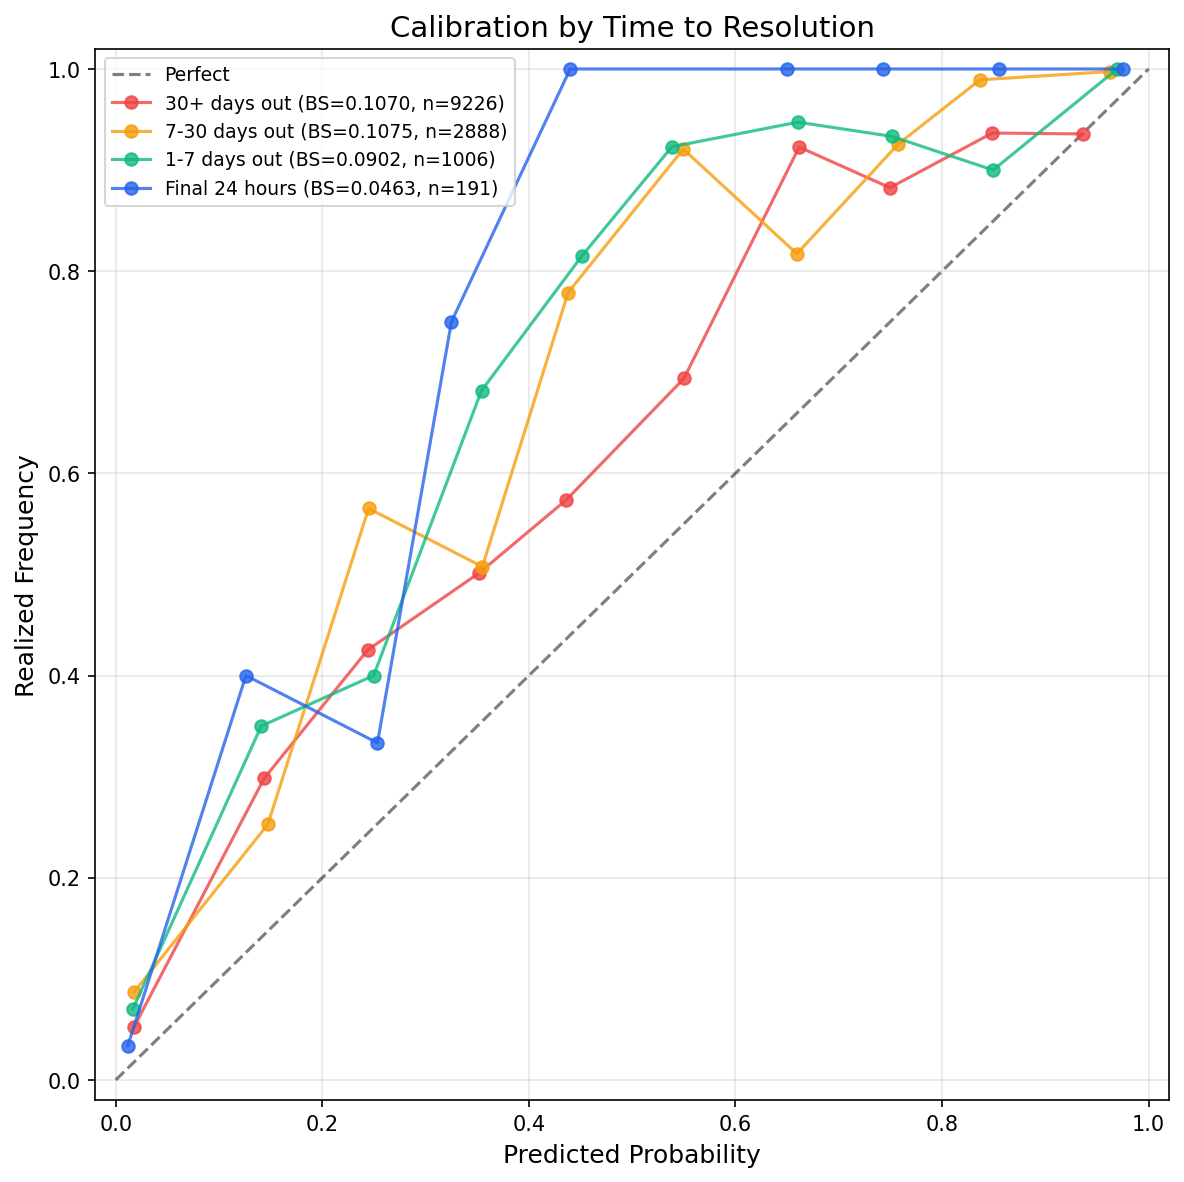

In [4]:
time_results = analysis_accuracy_over_time(cal_ds)
for horizon, tbl in time_results.items():
    print(f"\n=== {horizon} ===")
    display(tbl)
display(Image(f"{PLOTS}/accuracy_over_time.png"))
display(Image(f"{PLOTS}/calibration_by_time.png"))

## 4. Analysis B — Domain × Time Interaction

Does the category ranking hold across horizons, or does it reshuffle as resolution nears?


ANALYSIS B: Domain x Time Interaction
  Categories with enough data: ['Politics', 'Entertainment', 'Sports', 'Elections', 'Companies', 'Economics', 'Crypto', 'Financials', 'Social', 'Mentions', 'Science and Technology', 'World', 'Climate and Weather']



  Category                       30+ days     7-30 days      1-7 days    < 24 hours
  ---------------------------------------------------------------------------
  Politics                         0.0917        0.0843        0.0722        0.0682
  Entertainment                    0.1902        0.1367        0.0890        0.0500
  Sports                              ---        0.1678        0.3017        0.2325
  Elections                        0.1752        0.0953        0.0751           ---
  Companies                        0.1634        0.2159        0.2435        0.1679
  Economics                        0.1799        0.1475        0.0939        0.0676
  Crypto                              ---        0.1348        0.1729        0.3369
  Financials                       0.2924        0.5038        0.4652        0.3745
  Social                           0.1390        0.0416        0.0080           ---
  Mentions                         0.1840        0.1748        0.2516        0.24

  Saved domain_time_interaction.png
  Saved domain_time_heatmap.png


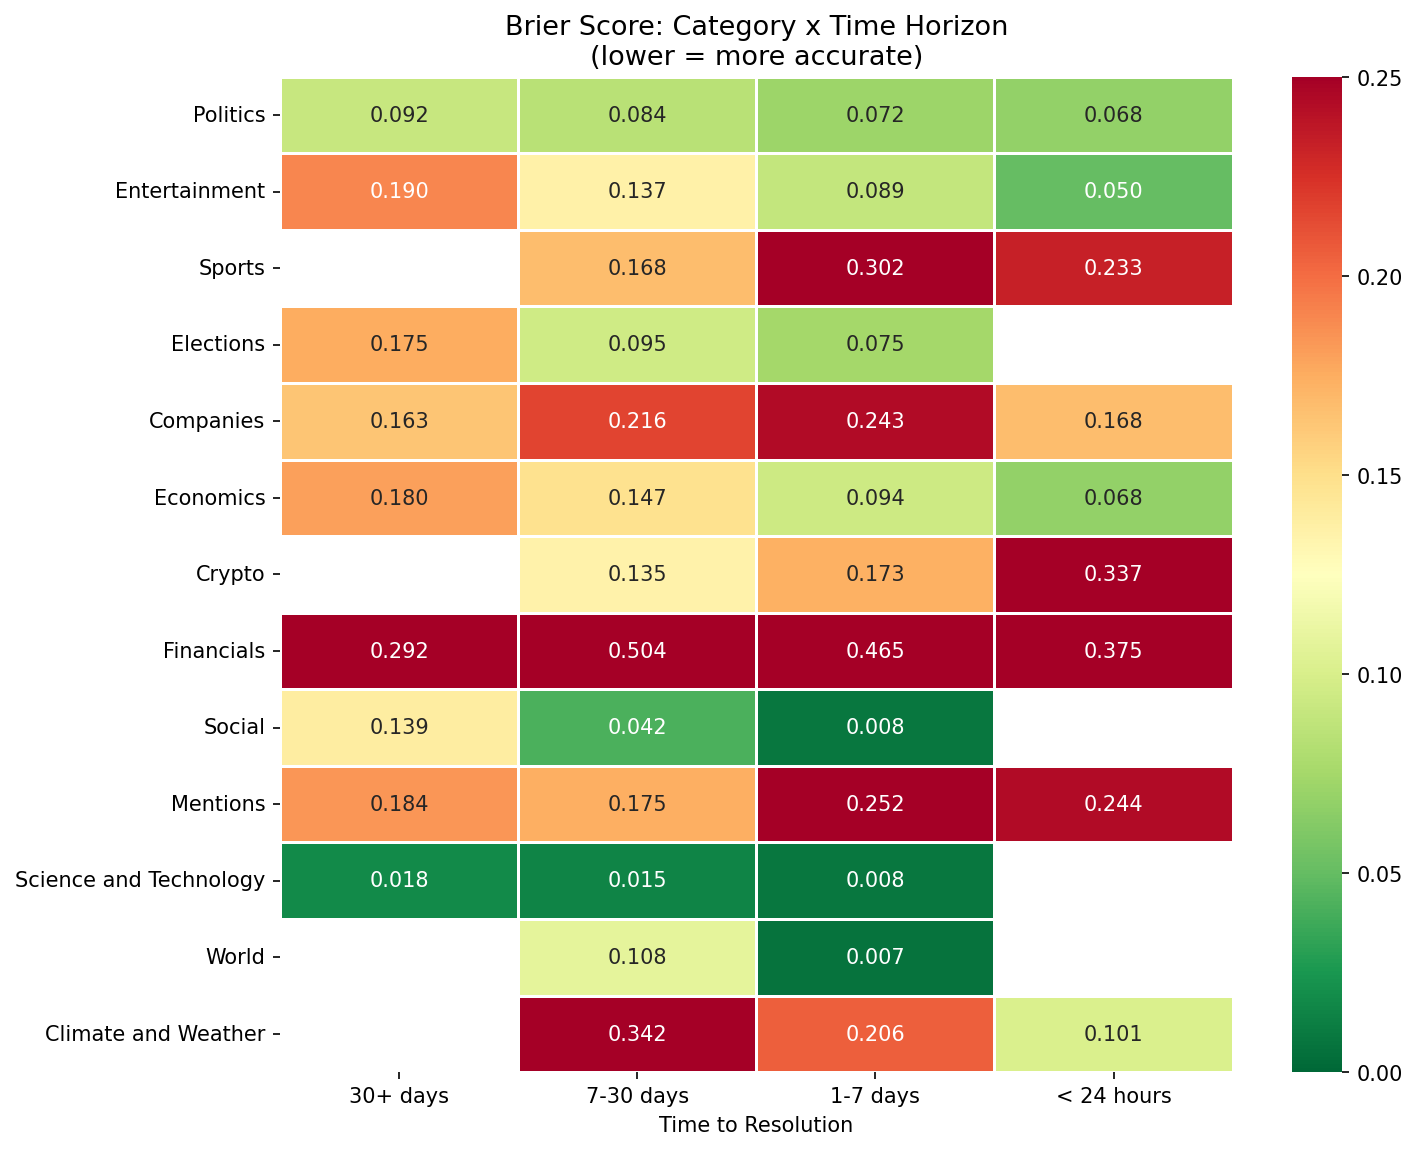

In [5]:
domain_matrix = analysis_domain_time(cal_ds)
display(Image(f"{PLOTS}/domain_time_heatmap.png"))

## 5. Analysis C — Liquidity / Volume

Does more volume buy better calibration? (Preview: Sports has 4.6× Politics' volume and
worse calibration — volume here does not buy accuracy.)


ANALYSIS C: Liquidity / Volume Effect
  medium      Brier=0.1117  n=621 (53 markets)
  high        Brier=0.1600  n=15174 (429 markets)


  Saved liquidity_effect.png


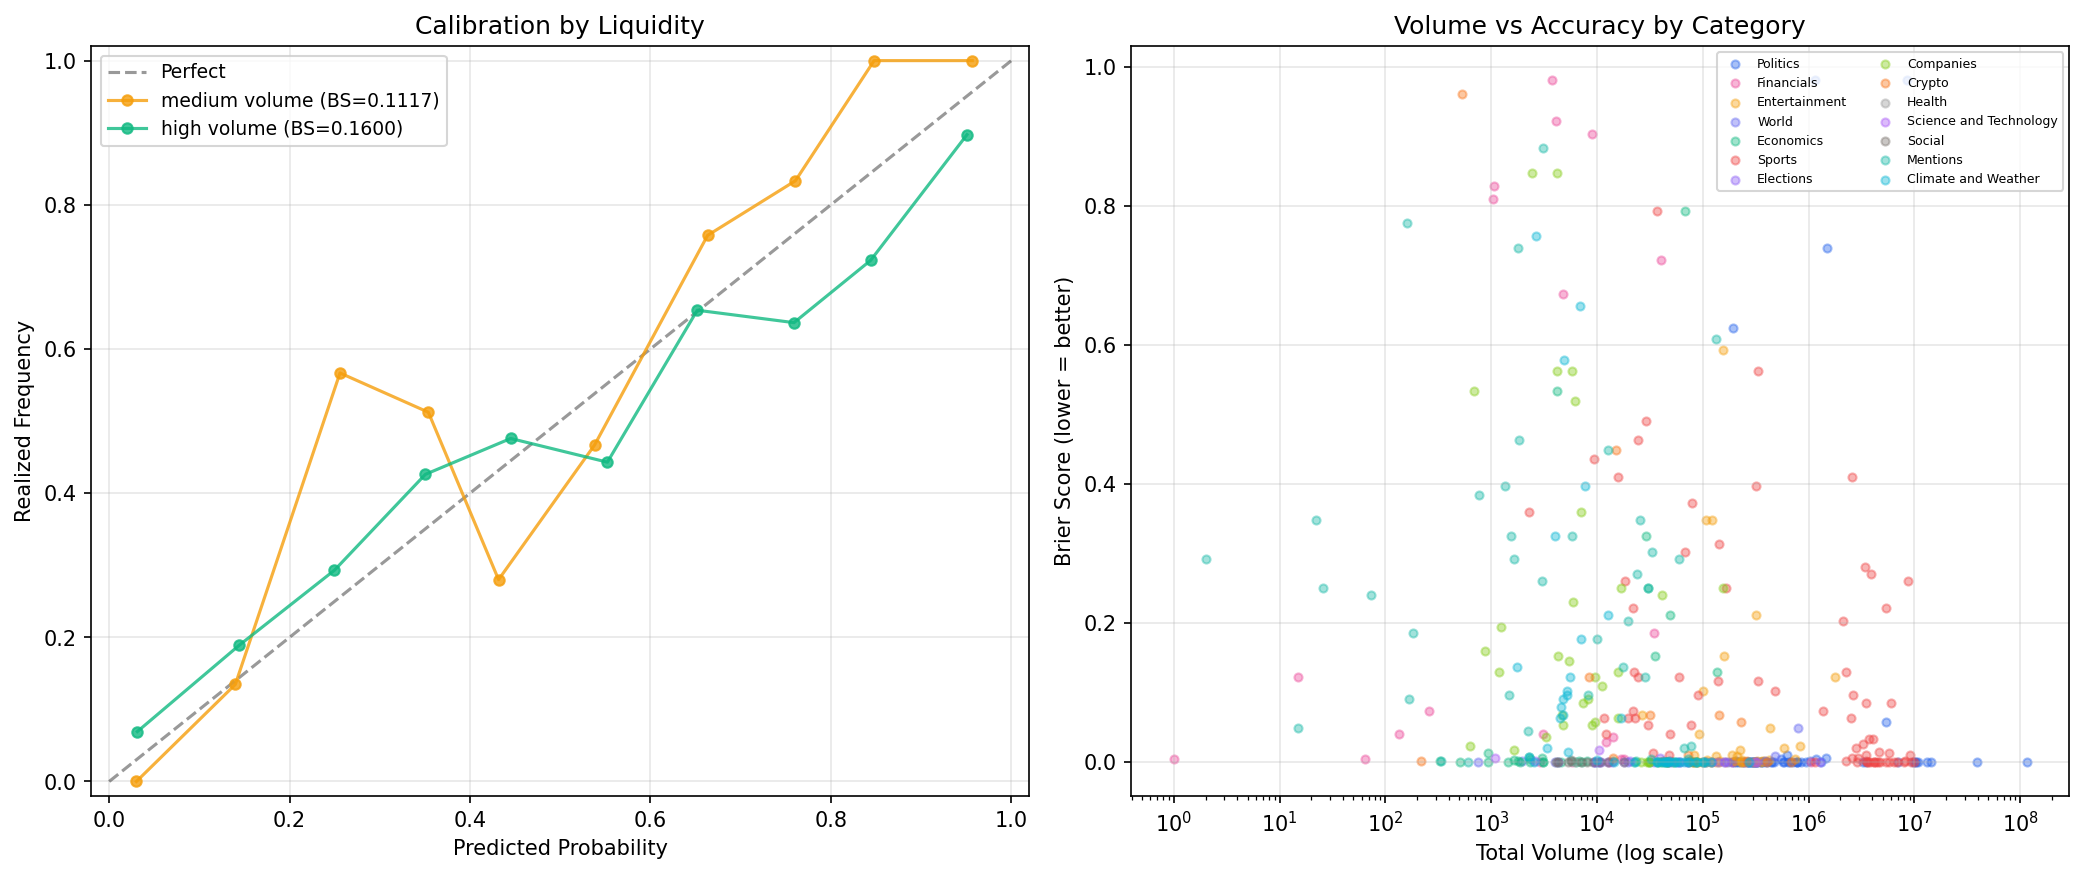

In [6]:
liq_results = analysis_liquidity(cal_ds, features)
display(Image(f"{PLOTS}/liquidity_effect.png"))

## 6. Analysis D — Why Do Calibration Differences Exist?

Feature correlations with Brier and per-category profiles (duration, spread, volatility,
volume), plus short narratives for the extreme categories.


ANALYSIS D: Why Do Calibration Differences Exist?

  Feature correlations with Brier score:
    Bid-Ask Spread             r=+0.2474  p=0.0000 *  n=430
    Total Volume               r=-0.3571  p=0.0000 *  n=430
    Price Updates              r=-0.3070  p=0.0000 *  n=430
    Duration (hrs)             r=-0.3237  p=0.0000 *  n=430
    Overall Volatility         r=+0.1053  p=0.0607    n=318
    Late Volatility            r=-0.0800  p=0.6428    n=36
    Late Price Move            r=+0.3843  p=0.0000 *  n=259
    Price Range                r=-0.2277  p=0.0000 *  n=430
    Late Volume Share          r=+0.2167  p=0.0001 *  n=312

  Category profiles (median values):
    Category                    Brier   Spread     Volume  Updates  LateVol  YesRate   Imbal
    ------------------------------------------------------------------------------------------
    Health                     0.0001   0.0814       6262       58      nan    1.000   0.500
    Elections                  0.0004   0.0301   

  Saved explanatory_scatter.png
  Saved category_profiles_heatmap.png


  Saved regression_coefficients.png


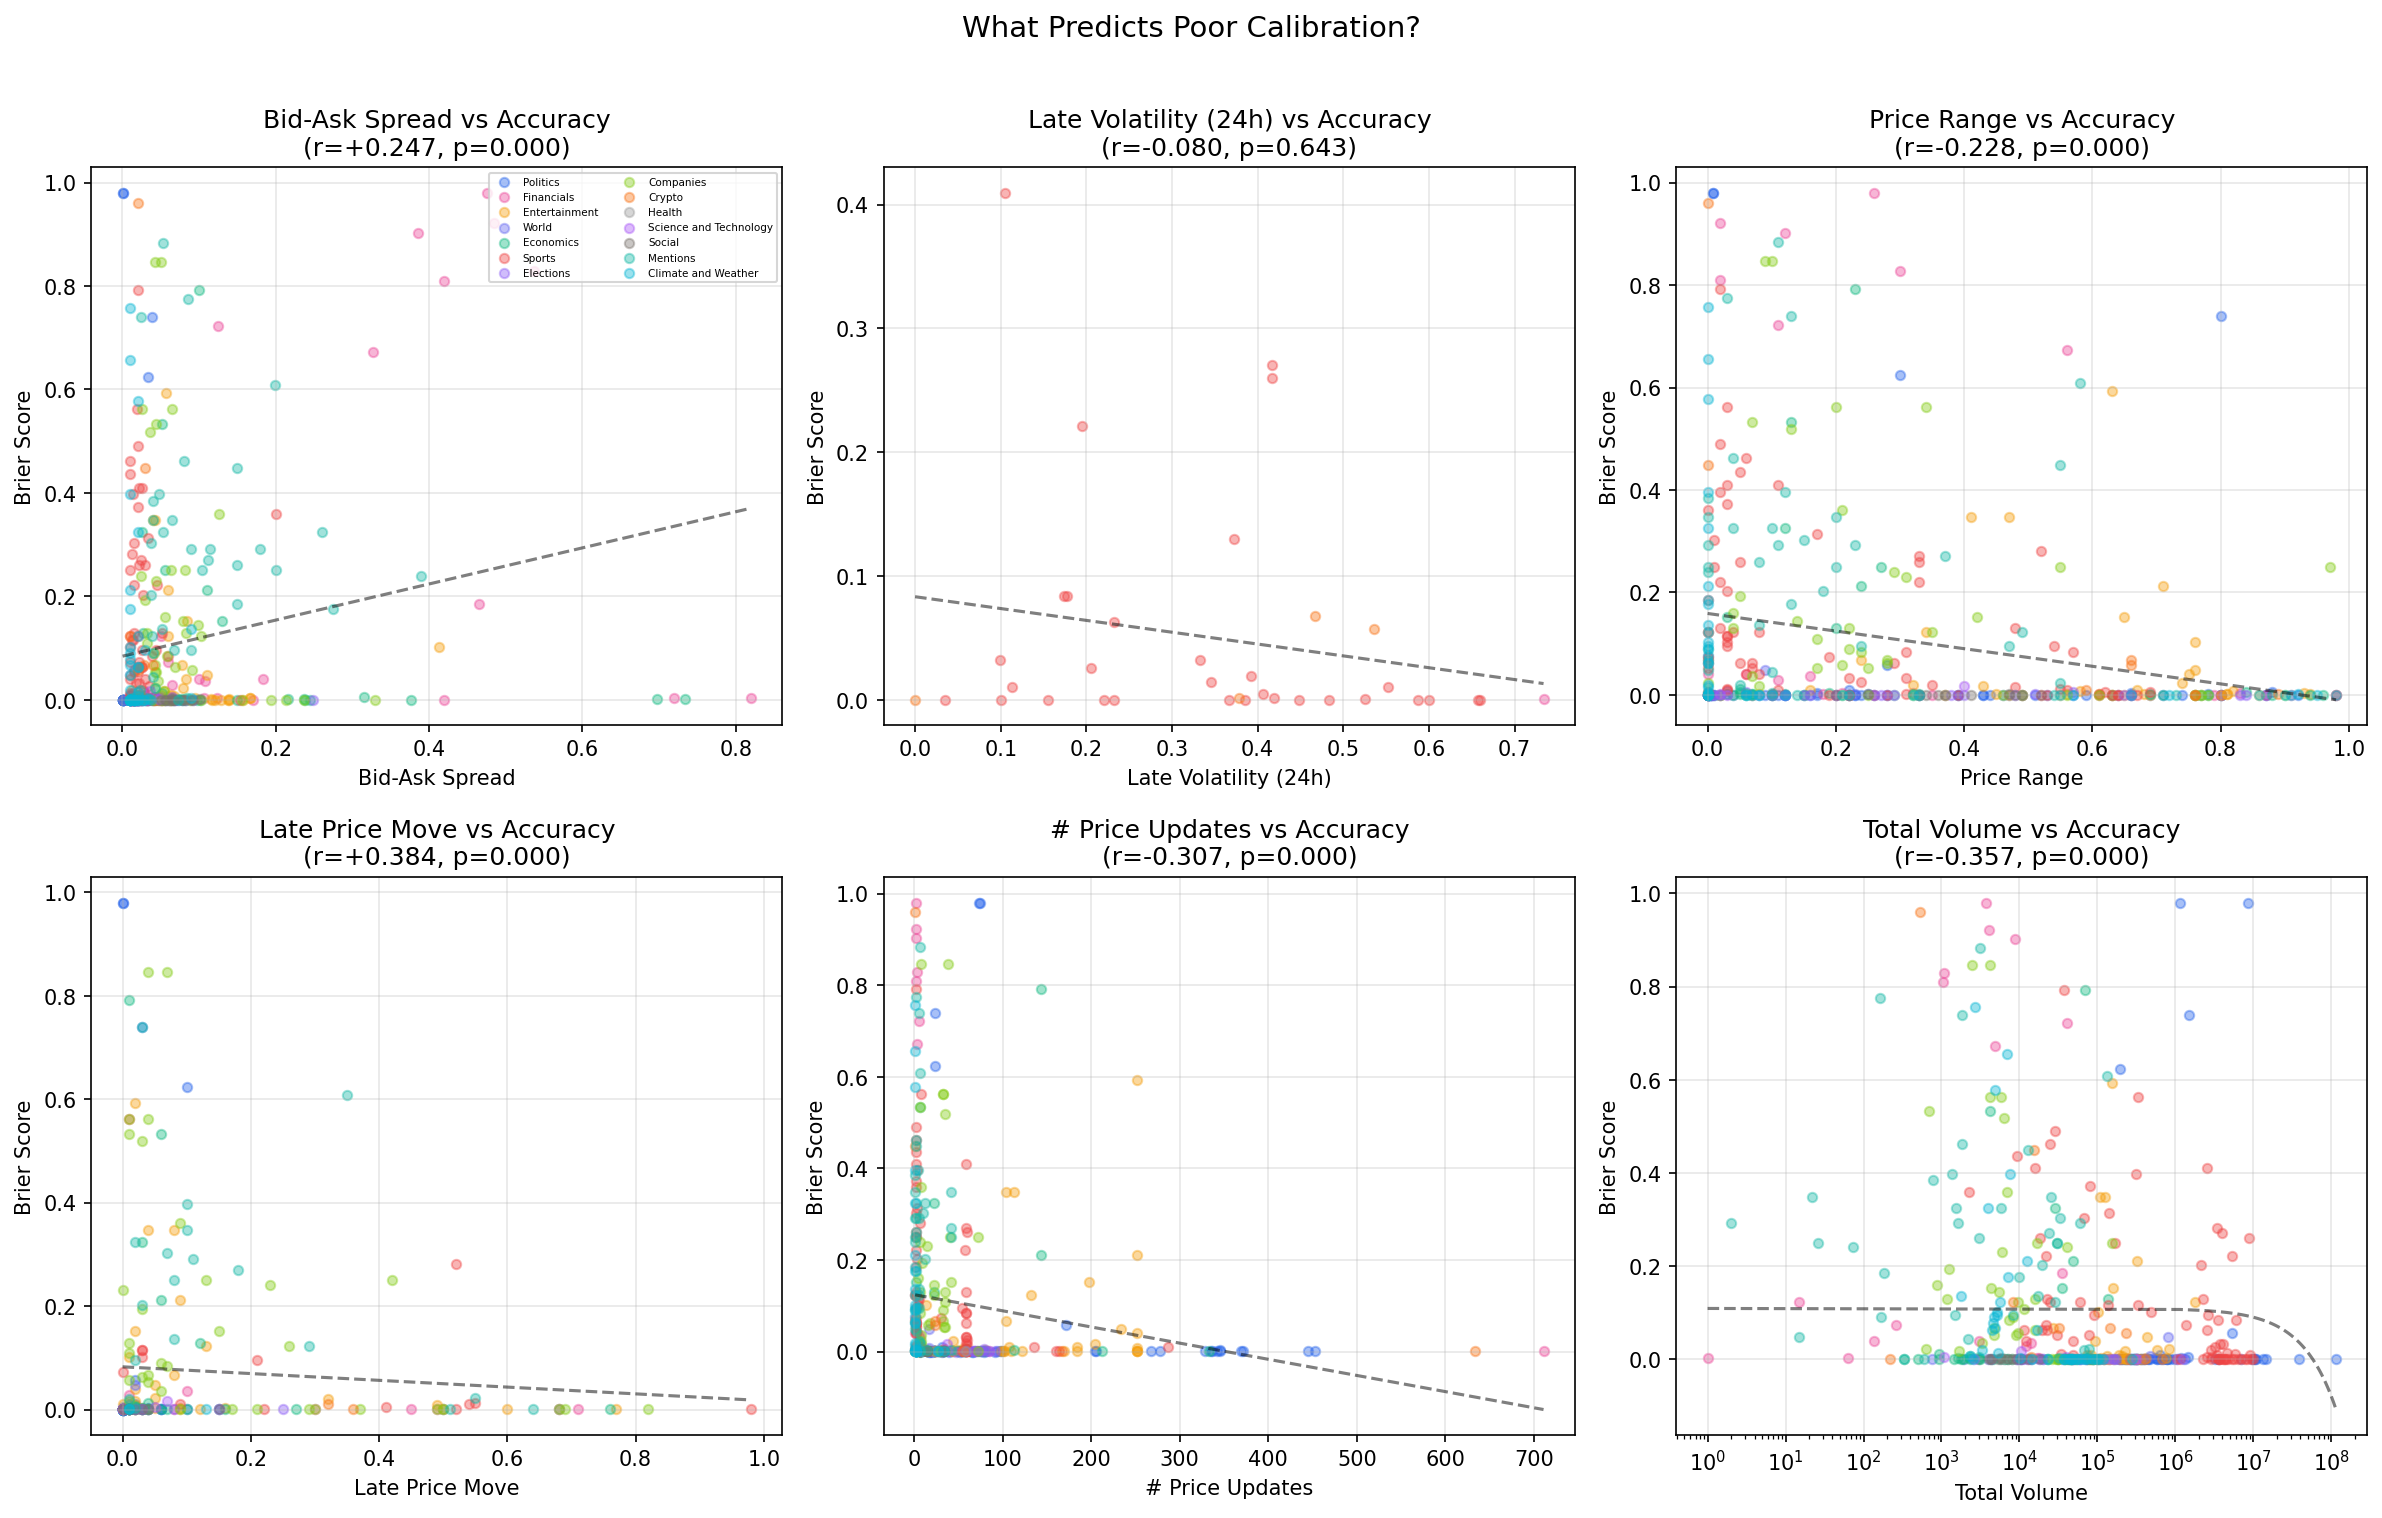

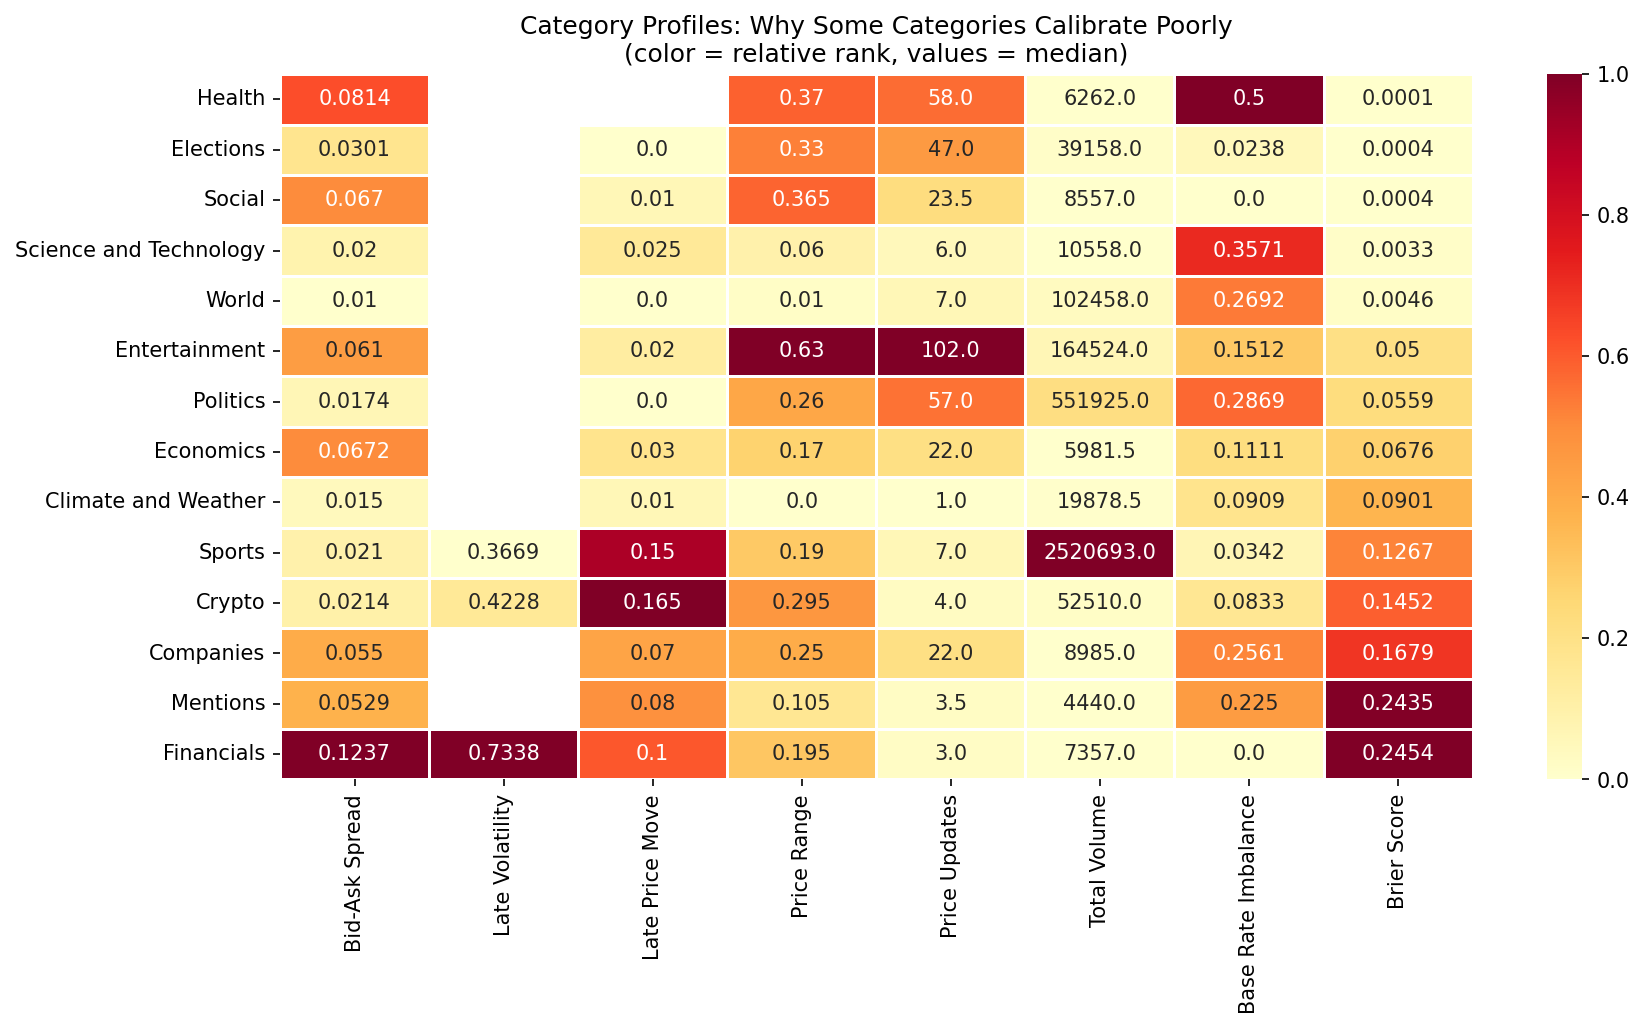

In [7]:
explanatory = analysis_explanatory(features)
display(Image(f"{PLOTS}/explanatory_scatter.png"))
display(Image(f"{PLOTS}/category_profiles_heatmap.png"))

## 7. Analysis E — Do Domain Effects Survive Controls?

Five OLS models on the observation-level data add microstructure controls progressively.
Two corrections vs. the original write-up: controls are now **point-in-time** (expanding
aggregates using only each observation's past, not its whole life), and standard errors
are **clustered by market** (observations from one market share a price path).

- **R² lift from domain: +4.9%** — domain adds signal beyond microstructure.
- Observation-level R² is **14.7%, not 23%** — the gap was lookahead: the old "price range"
  control was computed over the market's *entire life*, leaking how far price eventually
  travelled toward the outcome.
- Under clustered SEs, **5 of 12 categories** remain significantly different from Politics
  (not 11). **Financials** is the most robustly poorly-calibrated (+0.32 controlled,
  p=0.001). **Crypto no longer flips sign** — it stays indistinguishable from Politics.


ANALYSIS E: Do Domain Effects Survive Controls?

  Observations: 15774
  Markets: 483
  Categories: ['Climate and Weather', 'Companies', 'Crypto', 'Economics', 'Elections', 'Entertainment', 'Financials', 'Mentions', 'Politics', 'Science and Technology', 'Social', 'Sports', 'World']
  Reference category: Politics
  Reference horizon: 30+ days

  ────────────────────────────────────────────────────────
  MODEL 1: squared_error ~ domain
  ────────────────────────────────────────────────────────
  R² = 0.1377  Adj-R² = 0.1371  n = 15774
    Science and Technology    -0.0732  p=0.0155 *
    Social                    -0.0455  p=0.1543  
    World                     -0.0060  p=0.9264  
    Elections                 +0.0460  p=0.3601  
    Economics                 +0.0565  p=0.1824  
    Entertainment             +0.0746  p=0.0733  
    Crypto                    +0.0858  p=0.1683  
    Mentions                  +0.1241  p=0.0062 *
    Companies                 +0.1245  p=0.0098 *
    Climat

  R² = 0.1475  Adj-R² = 0.1464  n = 15774
    Social                    -0.0724  p=0.0142 *
    Science and Technology    -0.0517  p=0.3674  
    World                     -0.0206  p=0.7462  
    Elections                 +0.0138  p=0.7727  
    Economics                 +0.0322  p=0.4360  
    Entertainment             +0.0492  p=0.2029  
    Crypto                    +0.0620  p=0.2509  
    Mentions                  +0.1011  p=0.0344 *
    Companies                 +0.1111  p=0.0275 *
    Climate and Weather       +0.1257  p=0.1884  
    Sports                    +0.1542  p=0.0104 *
    Financials                +0.3188  p=0.0007 *
    (reference: Politics = 0.0000)
    1-7 days                  -0.0429  p=0.0425 *
    7-30 days                 -0.0414  p=0.0163 *
    < 24 hours                -0.0767  p=0.0839  
  Controls:
    log_volume                -0.002321  p=0.7598  
    pit_avg_spread            +0.051975  p=0.6660  
    pit_n_obs                 +0.000068  p=0.7726  
    d

  R² = 0.0989  Adj-R² = 0.0984  n = 15774

  ────────────────────────────────────────────────────────
  MODEL 5: squared_error ~ domain * horizon + controls
  ────────────────────────────────────────────────────────
  R² = 0.1688  Adj-R² = 0.1658  n = 15774
  Interaction terms: 36 total, 11 significant (p<0.05)

  MODEL COMPARISON
  Model                                               R²   Adj-R²        AIC
  ---------------------------------------------------------------------------
  1. Domain only                                  0.1377   0.1371    -3506.6
  2. Domain + horizon                             0.1426   0.1418    -3589.8
  3. Domain + horizon + controls                  0.1475   0.1464    -3669.4
  4. Controls only (no domain)                    0.0989   0.0984    -2818.0
  5. Domain × horizon + controls                  0.1688   0.1658    -3996.7

  KEY TEST: Domain effect after controls
    R² with domain:    0.1475
    R² without domain: 0.0989
    R² lift from domain: 

  Saved regression_controls.png


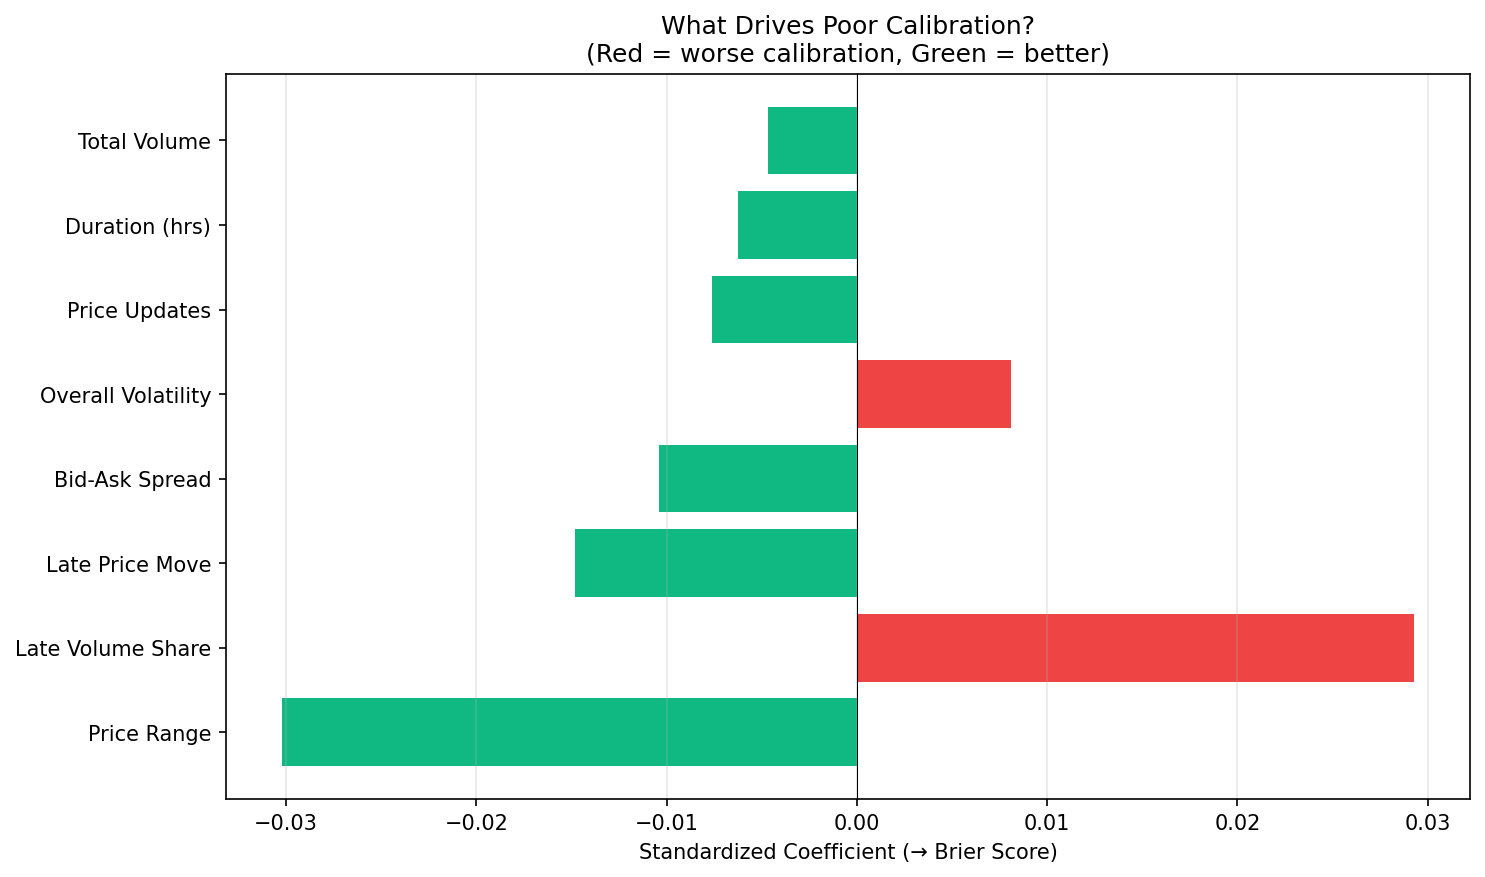

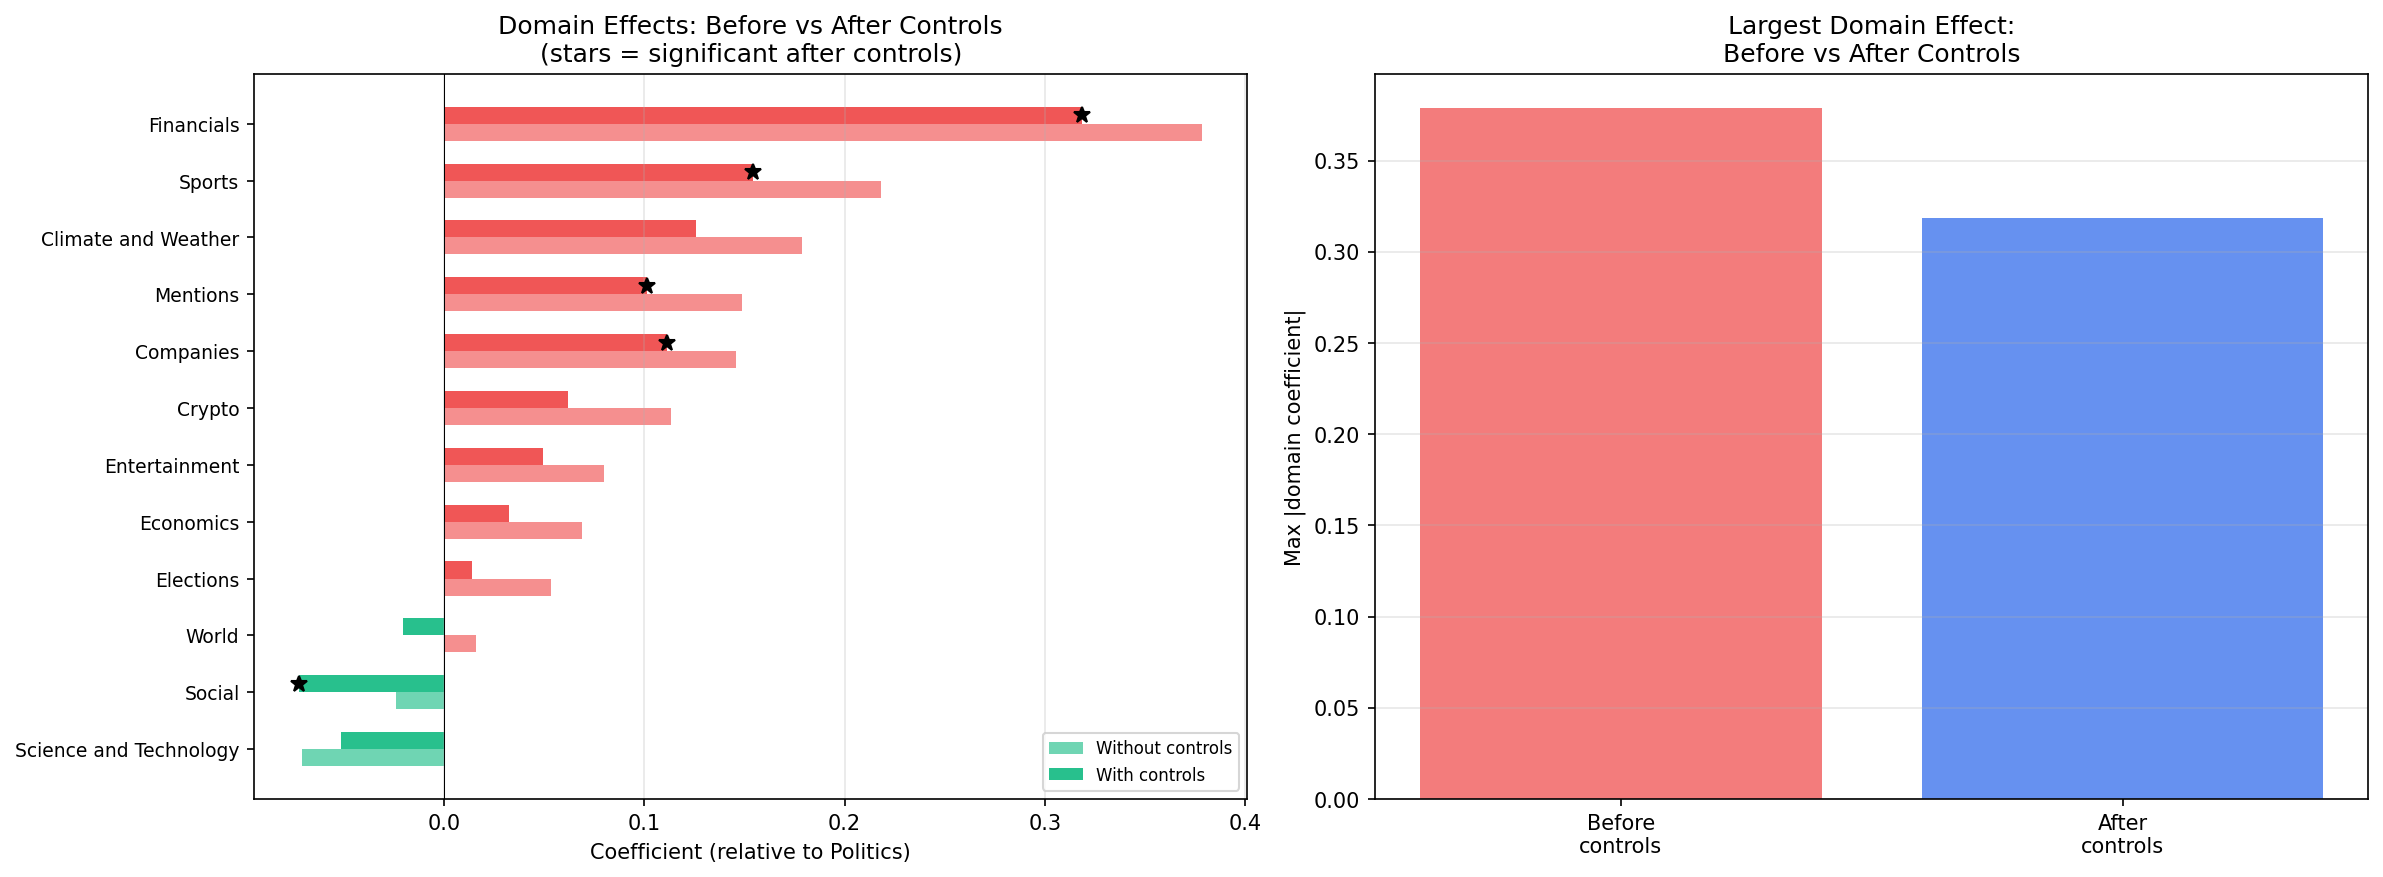

In [8]:
regression = analysis_regression(cal_ds, features)
display(Image(f"{PLOTS}/regression_coefficients.png"))
display(Image(f"{PLOTS}/regression_controls.png"))

## 8. Analysis F — Out-of-Sample Recalibration

A Platt-scaling recalibration layer per (category, horizon), evaluated with 5-fold CV split
by market, with corrected bootstrap CIs (the original collapsed duplicate draws via
`.isin()`, turning each replicate into a ~63% subsample).

**Overall ≈ 0 (−0.6% ± 0.7% Brier across fold splits)** — the earlier "+1.5%" was a single
lucky split. It helps exactly where miscalibration is large (Crypto, Financials, Companies)
and hurts small or already-good categories. A redistribution, not a free lunch.


ANALYSIS F: Out-of-Sample Recalibration Test
  Observations: 15774
  Markets: 483
  Categories: ['Climate and Weather', 'Companies', 'Crypto', 'Economics', 'Elections', 'Entertainment', 'Financials', 'Mentions', 'Politics', 'Science and Technology', 'Social', 'Sports', 'World']

  Running 5-fold cross-validation (split by market)...


    Fold 1: train=12758 obs, test=3016 obs
    Fold 2: train=12992 obs, test=2782 obs


    Fold 3: train=12360 obs, test=3414 obs


    Fold 4: train=12615 obs, test=3159 obs


    Fold 5: train=12371 obs, test=3403 obs

  OUT-OF-SAMPLE RESULTS (5-fold CV, all observations):
    Raw Brier:          0.1583
    Recalibrated Brier: 0.1671
    Improvement:        -5.6%



    Across 10 fold splits: mean -0.6%, sd 2.2, range [-5.6%, +2.2%]
    → No reliable overall improvement: the effect is indistinguishable
      from zero, and the single-split number is mostly split noise.

    Category                    Raw BS  Recal BS   Change      n
    ------------------------------------------------------------
    Climate and Weather         0.2331    0.3884   -66.7%    144
    Companies                   0.2137    0.1701   +20.4%    773
    Crypto                      0.1750    0.0614   +64.9%    713
    Economics                   0.1457    0.2161   -48.3%    766
    Elections                   0.1352    0.1959   -44.9%   1182
    Entertainment               0.1638    0.2047   -25.0%   2863
    Financials                  0.4469    0.1785   +60.0%    563
    Mentions                    0.2133    0.2299    -7.8%    302
    Politics                    0.0892    0.1068   -19.7%   5431
    Science and Technology      0.0161    0.0571  -255.8%    286
    Social 


  Domain effects with 95% bootstrap CIs (vs Politics):
    Category                    Effect                   95% CI   Sig
    ------------------------------------------------------------------
    Climate and Weather        +0.1402   [-0.0223, +0.3301]    No
    Companies                  +0.1274   [+0.0389, +0.2223]   Yes
    Crypto                     +0.1185   [-0.0046, +0.2950]    No
    Economics                  +0.0580   [-0.0266, +0.1467]    No
    Elections                  +0.0440   [-0.0487, +0.1409]    No
    Entertainment              +0.0769   [-0.0038, +0.1502]    No
    Financials                 +0.3053   [+0.0404, +0.4849]   Yes
    Mentions                   +0.1273   [+0.0349, +0.2126]   Yes
    Science and Technology     -0.0679   [-0.1306, -0.0076]   Yes
    Social                     -0.0452   [-0.1125, +0.0169]    No
    Sports                     +0.1793   [+0.0774, +0.3005]   Yes
    World                      -0.0142   [-0.1204, +0.1219]    No


  Saved recalibration_results.png


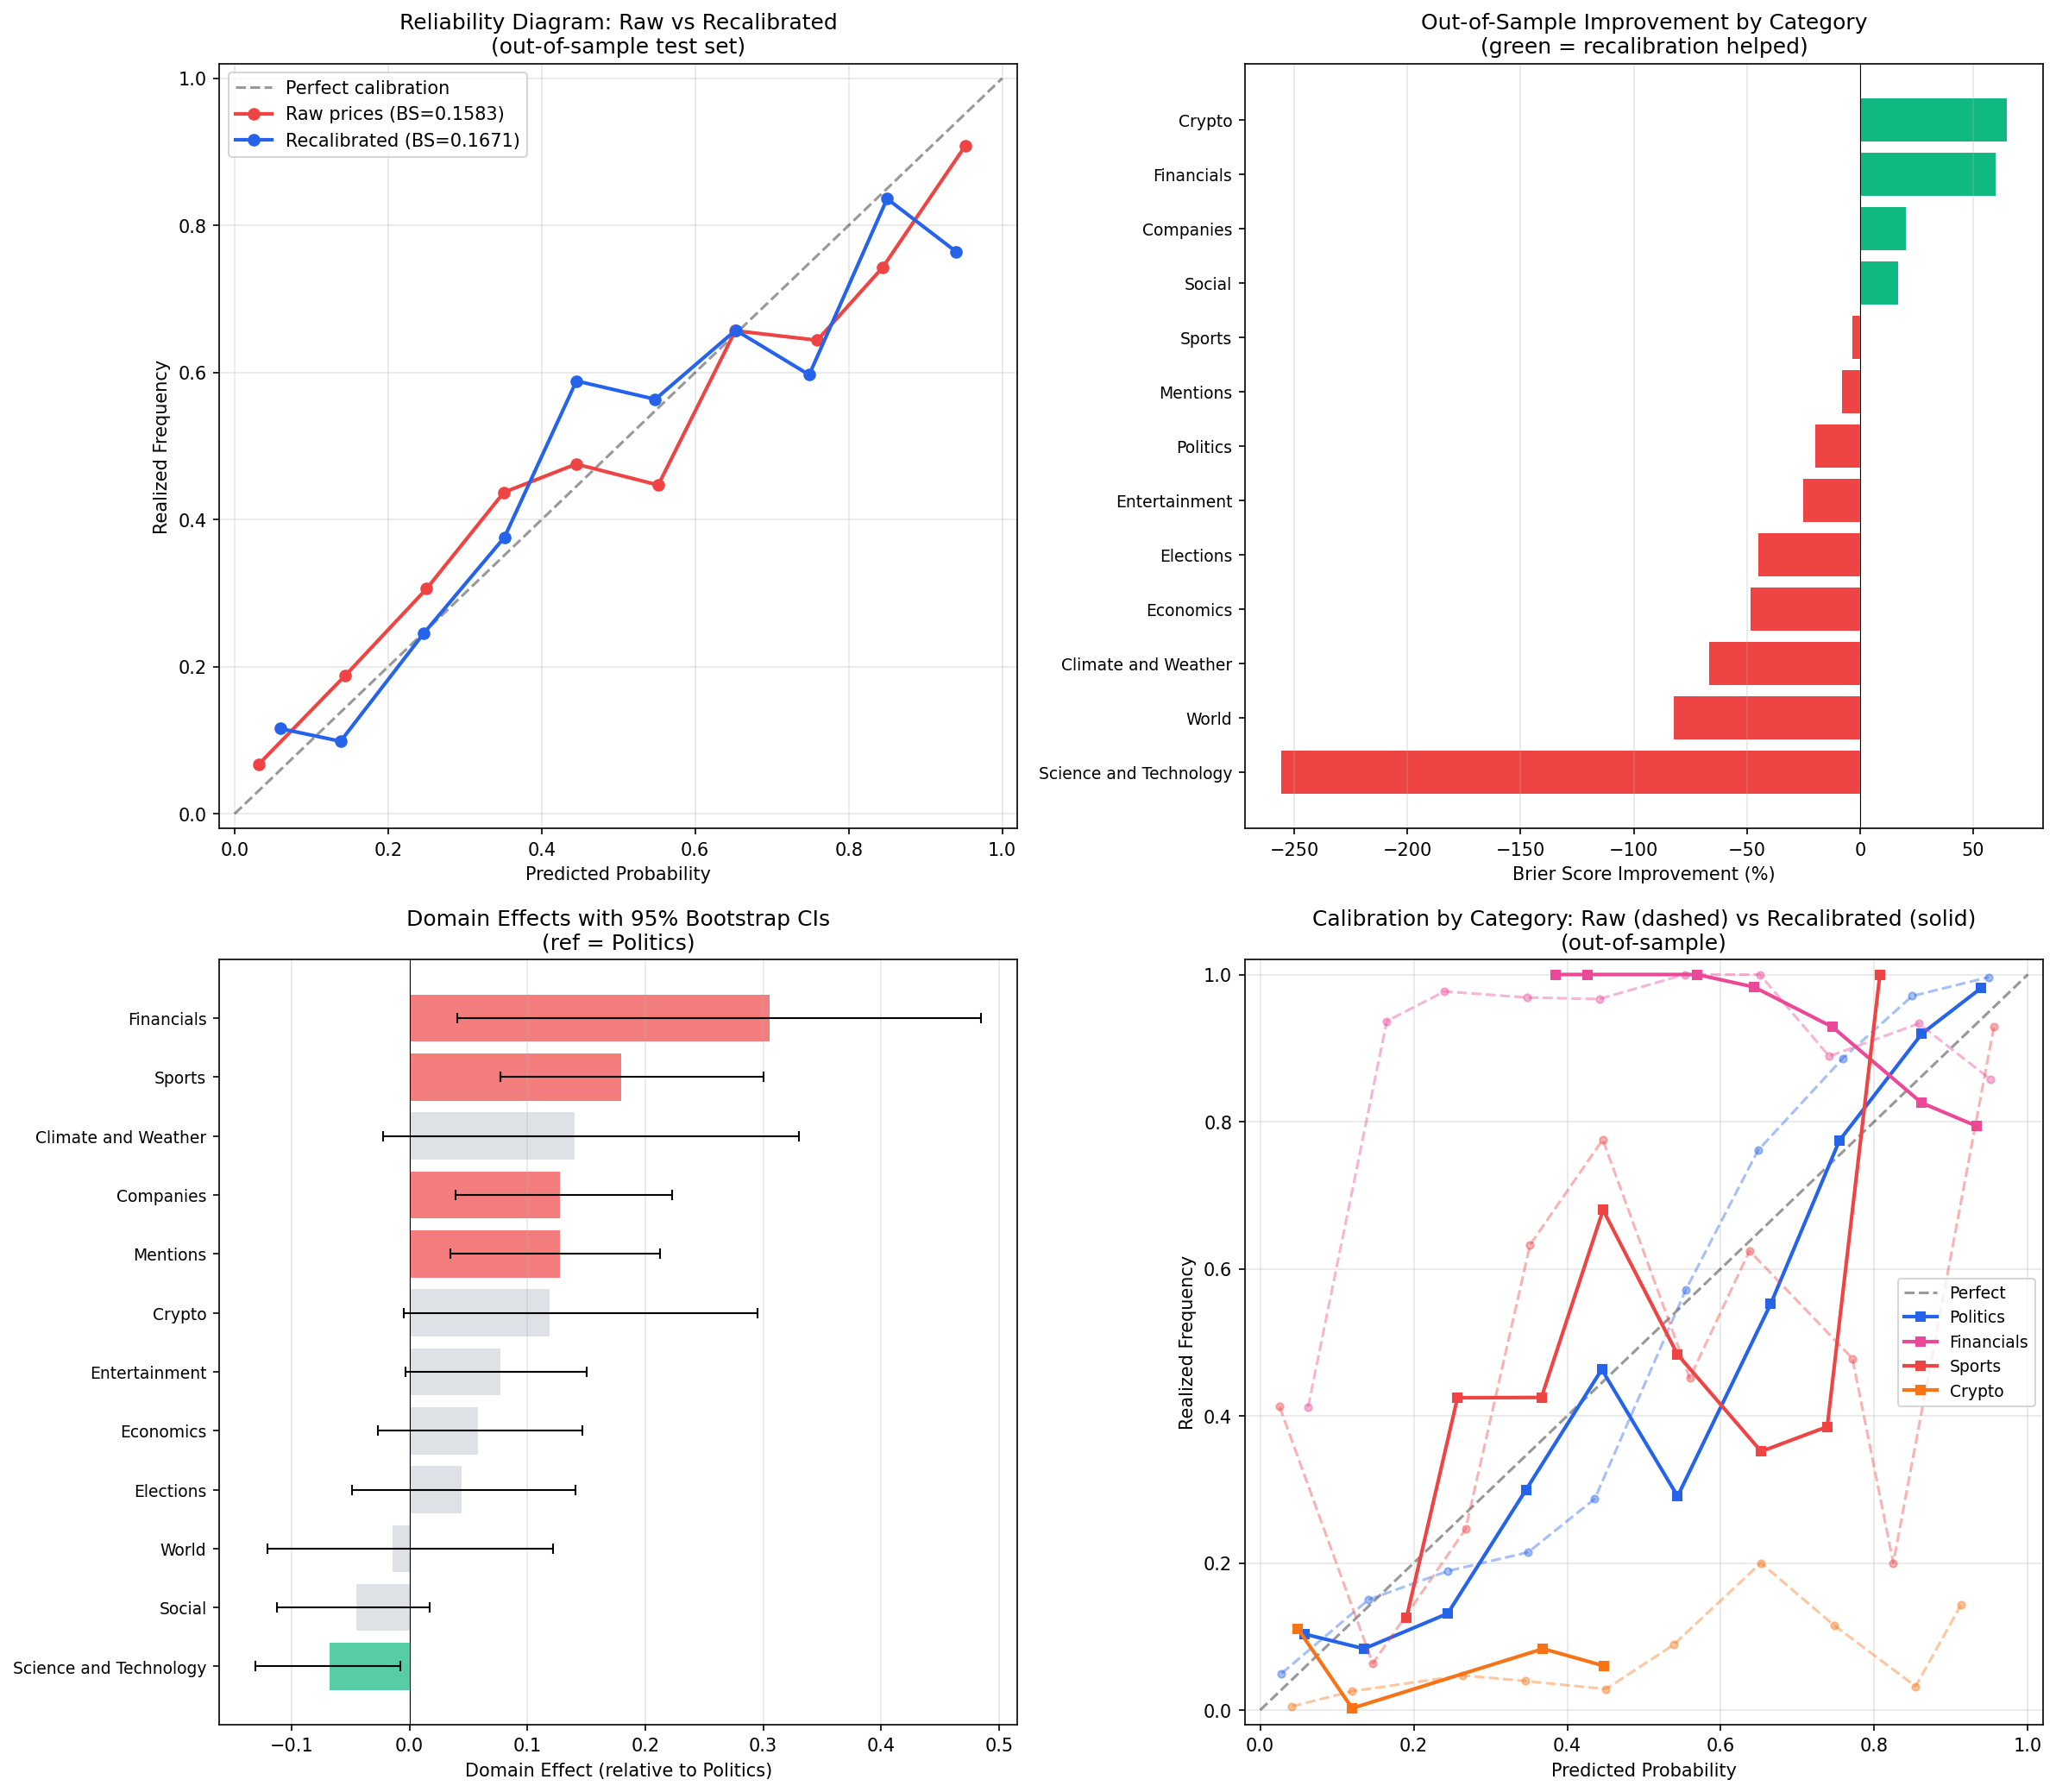

In [9]:
recalibration = analysis_recalibration(cal_ds, features)
display(Image(f"{PLOTS}/recalibration_results.png"))

## 9. Analysis G — Domain-Adjusted Probability Model + Robustness

A logistic model on price + domain + horizon earns a real **+5.2% out-of-sample Brier
improvement** over raw price — domain and horizon carry exploitable signal. But *adding*
microstructure features makes it **worse**, because that edge in the original write-up came
from the same lookahead that inflated the regression R². Robustness: alternative control
sets, a daily-clock-only subsample, and sample-size diagnostics.


ANALYSIS G: Domain-Adjusted Model + Robustness
  Observations: 15774
  Markets: 483
  Categories: ['Climate and Weather', 'Companies', 'Crypto', 'Economics', 'Elections', 'Entertainment', 'Financials', 'Mentions', 'Politics', 'Science and Technology', 'Social', 'Sports', 'World']

  ── Part 1: Domain-Adjusted Probability Model ──

  Running 5-fold CV for 3 model variants...



  OUT-OF-SAMPLE MODEL COMPARISON:
    Model                                       Brier   LogLoss   vs Raw
    --------------------------------------------------------------------
    Raw price only                             0.1639    0.5006 baseline
    Price + domain + horizon                   0.1555    0.4933    +5.2%
    Price + domain + horizon + micro           0.1614    0.5180    +1.5%

  PER-CATEGORY: Full model vs raw price only
    Category                    Raw BS   Full BS   Change      n
    ------------------------------------------------------------
    Climate and Weather         0.2303    0.3176   -37.9%    144
    Companies                   0.2022    0.1324   +34.5%    773
    Crypto                      0.1532    0.0523   +65.9%    713
    Economics                   0.1560    0.1293   +17.1%    766
    Elections                   0.1353    0.1671   -23.5%   1182
    Entertainment               0.1765    0.1943   -10.1%   2863
    Financials                  0.

  Microstructure (volume + spread + duration)   0.1468  +0.0903      4
  Full (all 6 controls)                         0.1475  +0.0485      5


  No spread                                     0.1473  +0.0489      5
  No volume                                     0.1472  +0.0484      5


  Full, daily-clock markets only                0.0787  +0.0291      4

  KEY CATEGORY COEFFICIENTS ACROSS CONTROL SETS:
  Control Set                             Crypto   Financia     Sports   Science    Entertai
  -------------------------------------------------------------------------------------
  Minimal (volume + spread)             +0.1048    +0.3639*   +0.2044*   -0.0868*   +0.0681 
  Microstructure (volume + spread + duration)   +0.0882    +0.3487*   +0.1886*   -0.0567    +0.0613 
  Full (all 6 controls)                 +0.0620    +0.3188*   +0.1542*   -0.0517    +0.0492 
  No spread                             +0.0607    +0.3198*   +0.1542*   -0.0532    +0.0500 
  No volume                             +0.0679    +0.3230*   +0.1561*   -0.0448    +0.0522 
  Full, daily-clock markets only        +0.0439    +0.1408    +0.1190*   -0.0642    +0.0550 

  ── Part 3: Sample-Size Diagnostics ──

  How stable are domain effects as sample size changes?

  Category                       

  Crypto                       +0.1523     +0.0776*    +0.0720     +0.0620          No


  Financials                   +0.1016     +0.1350*    +0.3222*    +0.3188*        Yes
  Sports                       +0.2940*    +0.1179*    +0.1002*    +0.1542*        Yes


  Science and Technology       +0.0246     -0.1141*    +0.0100     -0.0517          No


  Entertainment                +0.1060     +0.0585     +0.0398     +0.0492          No


  Saved adjusted_model_robustness.png


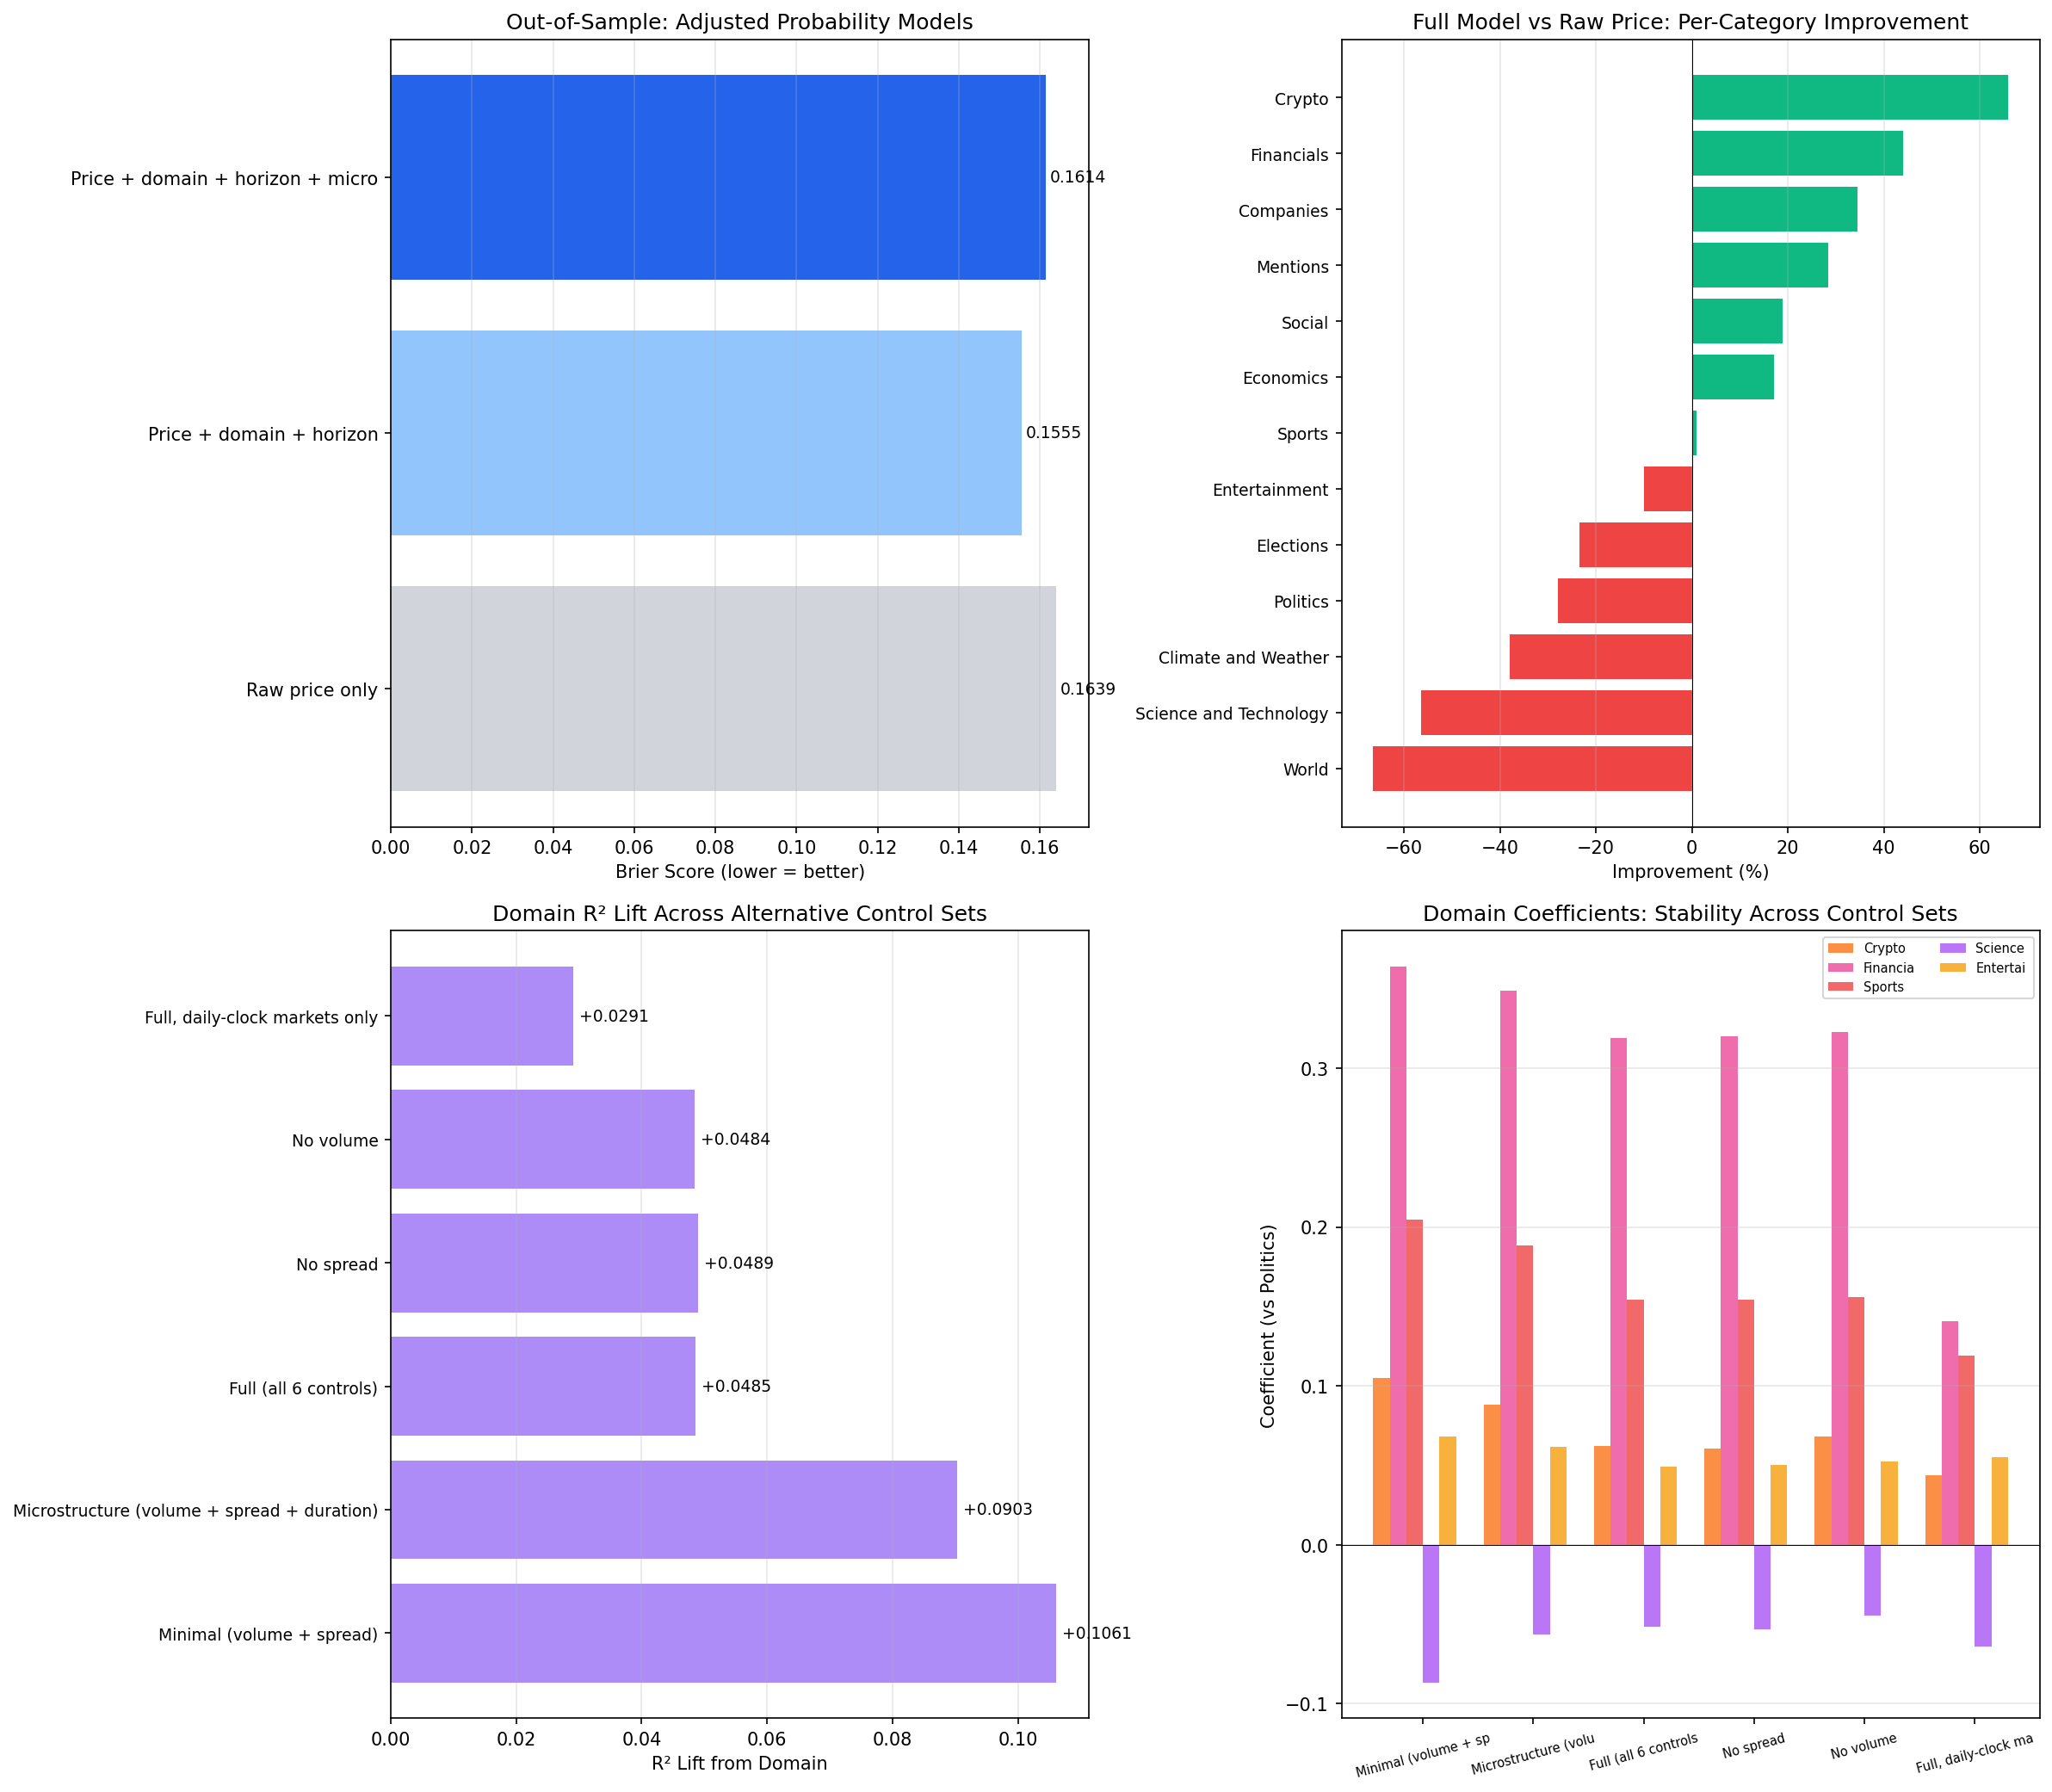

In [10]:
adjusted = analysis_adjusted_model(cal_ds, features)
display(Image(f"{PLOTS}/adjusted_model_robustness.png"))

## 10. Conclusion

**Category and horizon do mean something beyond raw price**, and a model conditioning on
them beats raw price out-of-sample. But the effect is modest, concentrated in a few badly-
calibrated categories (Financials worst; Sports poor despite high volume), and does **not**
support a general-purpose recalibration layer.

Honest bottom line, after fixing the artifacts:
- The last traded price is not a forecast — score before the outcome is public.
- Domain signal is real but smaller than first reported (R² 14.7%, not 23%).
- Crypto is indistinguishable from Politics — the sign-flip was an artifact.
- Out-of-sample recalibration ≈ 0 overall.

In [11]:
summary = compute_summary_stats(features, cal_ds)
print("Summary stats:")
for k, v in summary.items():
    if not isinstance(v, (dict, list)):
        print(f"  {k}: {v}")
conn.close()

Summary stats:
  total_markets: 430
  total_observations: 15822
  n_categories: 13
  n_categories_all: 14
  yes_outcomes: 162
  no_outcomes: 268
  overall_brier_score: 0.1071
  overall_brier_1d_before: 0.3059
  overall_brier_7d_before: 0.252
  overall_log_loss: 0.3402
  mean_volume: 1144654
  median_volume: 49254
  mean_duration_hours: 1047.9
  n_hourly_clock_markets: 36
